In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from econml.dml import CausalForestDML

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

## 2. Data loading

In [2]:
URL_BASE = "https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/master/datasets/IHDP/csv/"
LOCAL_DIR = "."   # put downloaded ihdp_npci_*.csv files here to avoid the download

def load_ihdp(rep=1):
    fname = f"ihdp_npci_{rep}.csv"
    local = os.path.join(LOCAL_DIR, fname)
    path = local if os.path.exists(local) else URL_BASE + fname
    d = pd.read_csv(path, header=None)
    t   = d[0].values.astype(int)
    yf  = d[1].values
    mu0 = d[3].values
    mu1 = d[4].values
    x   = d.iloc[:, 5:].values.astype(float)
    # some binary covariates are coded 1/2 instead of 0/1
    for j in range(x.shape[1]):
        if set(np.unique(x[:, j])) == {1.0, 2.0}:
            x[:, j] -= 1
    return t, yf, mu0, mu1, x

t, yf, mu0, mu1, x = load_ihdp(1)
ite_true = mu1 - mu0
ate_true = ite_true.mean()

print("shape of covariates:", x.shape)
print("treated:", t.sum(), "of", len(t))
print("true ATE:", round(ate_true, 3))

shape of covariates: (747, 25)
treated: 139 of 747
true ATE: 4.016


## 3. Naive estimate

Compare mean outcomes of treated and untreated units directly. This ignores confounding.

In [3]:
naive = yf[t == 1].mean() - yf[t == 0].mean()
print(f"naive estimate: {naive:.3f} | true ATE: {ate_true:.3f} | abs error: {abs(naive - ate_true):.3f}")

naive estimate: 4.021 | true ATE: 4.016 | abs error: 0.005


## 4. Propensity scores and IPW

The propensity score is $$e(X) = P(T = 1 \mid X)$$. We estimate it with logistic regression and reweight units by $$1/e(X)$$ for treated units and $$1/(1-e(X))$$ for untreated units. We clip estimated scores to [0.05, 0.95] to limit extreme weights.




In [4]:
ps_model = LogisticRegression(max_iter=5000).fit(x, t)
e = ps_model.predict_proba(x)[:, 1]
e_clip = np.clip(e, 0.05, 0.95)

# raw IPW
ate_ipw_raw = np.mean(t * yf / e_clip - (1 - t) * yf / (1 - e_clip))

# normalized (stabilized) IPW
w1 = t / e_clip
w0 = (1 - t) / (1 - e_clip)
ate_ipw = (w1 * yf).sum() / w1.sum() - (w0 * yf).sum() / w0.sum()

print(f"IPW raw        : {ate_ipw_raw:.3f} | abs error: {abs(ate_ipw_raw - ate_true):.3f}")
print(f"IPW normalized : {ate_ipw:.3f} | abs error: {abs(ate_ipw - ate_true):.3f}")
print(f"propensity range: {e.min():.3f} to {e.max():.3f}")
print(f"units clipped: {(e != e_clip).sum()}")

IPW raw        : 3.408 | abs error: 0.608
IPW normalized : 4.029 | abs error: 0.013
propensity range: 0.015 to 0.596
units clipped: 63


The Horvitz–Thompson IPW estimator can be sensitive to extreme propensity scores because \(1/e(X)\) or \(1/(1-e(X))\) can become very large. Clipping limits the largest weights. The normalized (Hájek) estimator additionally normalizes the weighted outcomes within each treatment group, which can reduce finite-sample instability.

Clipping is a practical variance-control choice; it can also introduce some bias, so the clipping threshold should be reported rather than treated as innocuous.


## 5. Overlap / positivity check

Positivity requires that, for the covariate patterns relevant to the target population, both treatment states have a non-zero probability of occurring:

$$
0 < P(T=1 \mid X) < 1.
$$

We inspect the propensity-score distributions for treated and untreated units. Strong overlap means that comparable treated and untreated units exist across the covariate space. Poor overlap makes causal estimates more dependent on extrapolation and can produce unstable IPW weights.


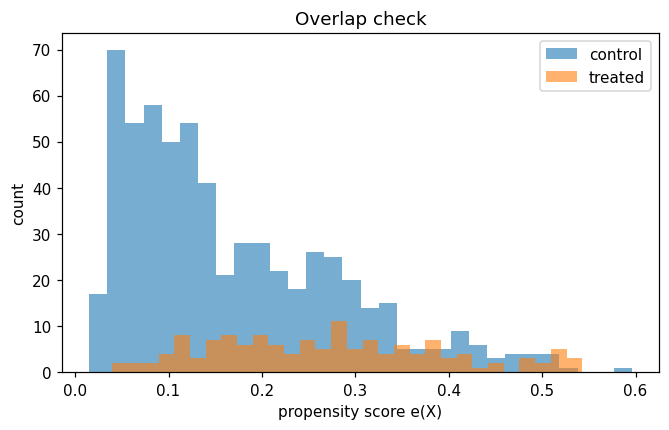

effective sample size (treated): 97.1 of 139
effective sample size (control): 591.4 of 608


In [5]:
plt.figure(figsize=(7, 4))
plt.hist(e[t == 0], bins=30, alpha=0.6, label="control")
plt.hist(e[t == 1], bins=30, alpha=0.6, label="treated")
plt.xlabel("propensity score e(X)")
plt.ylabel("count")
plt.title("Overlap check")
plt.legend()
plt.show()

ess1 = w1.sum()**2 / (w1**2).sum()
ess0 = w0.sum()**2 / (w0**2).sum()
print(f"effective sample size (treated): {ess1:.1f} of {t.sum()}")
print(f"effective sample size (control): {ess0:.1f} of {(1 - t).sum()}")

## 6. Causal forest

`CausalForestDML` first removes the part of the outcome and of the treatment explained by the covariates (double machine learning with cross-fitting), then grows honest trees that split to separate units with different treatment effects. The output is an estimated individual treatment effect (ITE) for every unit.

Evaluation metrics (both use the ground truth):
- **PEHE** = sqrt(mean((estimated ITE − true ITE)²)), the typical error on individual effects.
- **ε_ATE** = |mean estimated ITE − true ATE|.

In [6]:
cf = CausalForestDML(discrete_treatment=True, n_estimators=500, random_state=0)
cf.fit(yf, t, X=x)
ite_hat = cf.effect(x).ravel()

pehe = np.sqrt(np.mean((ite_hat - ite_true) ** 2))
eps_ate = abs(ite_hat.mean() - ate_true)

print(f"forest mean ITE: {ite_hat.mean():.3f} | true ATE: {ate_true:.3f}")
print(f"PEHE: {pehe:.3f} | eps_ATE: {eps_ate:.3f}")

forest mean ITE: 3.818 | true ATE: 4.016
PEHE: 0.501 | eps_ATE: 0.198


## 7. Estimated vs true ITEs

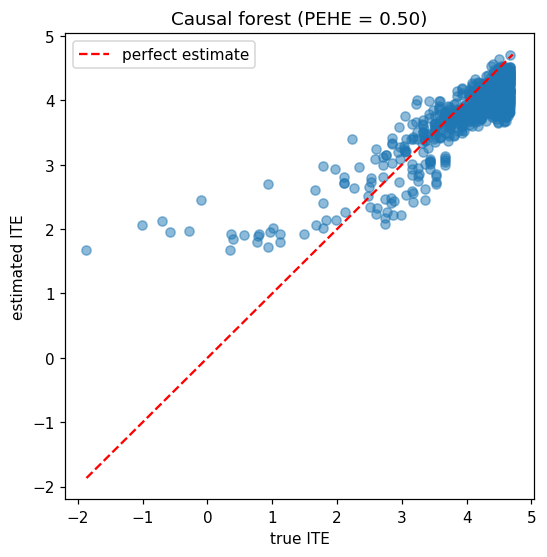

correlation(true, estimated): 0.873


In [7]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(ite_true, ite_hat, alpha=0.5)
lims = [min(ite_true.min(), ite_hat.min()), max(ite_true.max(), ite_hat.max())]
plt.plot(lims, lims, "r--", label="perfect estimate")
plt.xlabel("true ITE")
plt.ylabel("estimated ITE")
plt.title(f"Causal forest (PEHE = {pehe:.2f})")
plt.legend()
plt.show()

print("correlation(true, estimated):", round(np.corrcoef(ite_true, ite_hat)[0, 1], 3))

## 8. Overlap and forest error

Does the forest do worse where overlap is poor? We quantify overlap using
$$
min(e(X), 1-e(X)),
$$

where values closer to 0 indicate poorer overlap and values closer to 0.5 indicate better overlap. We compare PEHE across quintiles of this overlap score and separately compare the lowest-overlap decile with the remaining units.


In [8]:
overlap_score = np.minimum(e, 1 - e)
q = pd.qcut(overlap_score, 5, labels=False, duplicates="drop")

rows = []
for k in sorted(pd.Series(q).dropna().unique()):
    m = q == k
    rows.append({
        "overlap quintile": int(k) + 1,
        "overlap score range": f"{overlap_score[m].min():.2f} to {overlap_score[m].max():.2f}",
        "n": int(m.sum()),
        "treated": int(t[m].sum()),
        "control": int((1 - t[m]).sum()),
        "PEHE": np.sqrt(np.mean((ite_hat[m] - ite_true[m]) ** 2)),
    })

quintile_table = pd.DataFrame(rows)
display(quintile_table.round(3))

lo = np.quantile(overlap_score, 0.10)
poor = overlap_score <= lo

print(f"\nlowest-overlap decile (overlap score <= {lo:.3f}): n = {poor.sum()}, "
      f"PEHE = {np.sqrt(np.mean((ite_hat[poor] - ite_true[poor])**2)):.3f}")
print(f"all other units: n = {(~poor).sum()}, "
      f"PEHE = {np.sqrt(np.mean((ite_hat[~poor] - ite_true[~poor])**2)):.3f}")


,overlap quintile,overlap score range,n,treated,control,PEHE
0,1,0.02 to 0.07,150,4,146,0.531
1,2,0.07 to 0.12,149,14,135,0.461
2,3,0.12 to 0.20,149,28,121,0.509
3,4,0.20 to 0.29,149,35,114,0.431
4,5,0.29 to 0.50,150,58,92,0.559



lowest-overlap decile (overlap score <= 0.052): n = 75, PEHE = 0.469
all other units: n = 672, PEHE = 0.504


## 9. Robustness: 10 replications




In [9]:
N_REPS = 10
rows = []
for r in range(1, N_REPS + 1):
    t_, y_, m0_, m1_, x_ = load_ihdp(r)
    tau = m1_ - m0_

    naive_ = y_[t_ == 1].mean() - y_[t_ == 0].mean()

    e_ = np.clip(LogisticRegression(max_iter=5000).fit(x_, t_).predict_proba(x_)[:, 1], 0.05, 0.95)
    a1, a0 = t_ / e_, (1 - t_) / (1 - e_)
    ipw_ = (a1 * y_).sum() / a1.sum() - (a0 * y_).sum() / a0.sum()

    cf_ = CausalForestDML(discrete_treatment=True, n_estimators=500, random_state=0).fit(y_, t_, X=x_)
    ih = cf_.effect(x_).ravel()

    rows.append({
        "rep": r,
        "true_ate": tau.mean(),
        "tau_std": tau.std(),
        "naive_err": abs(naive_ - tau.mean()),
        "ipw_err": abs(ipw_ - tau.mean()),
        "cf_eps_ate": abs(ih.mean() - tau.mean()),
        "cf_pehe": np.sqrt(np.mean((ih - tau) ** 2)),
    })

res = pd.DataFrame(rows)
display(res.round(3))

,rep,true_ate,tau_std,naive_err,ipw_err,cf_eps_ate,cf_pehe
0,1,4.016,0.859,0.005,0.013,0.198,0.501
1,2,4.051,0.821,0.031,0.021,0.207,0.585
2,3,4.099,0.916,0.095,0.050,0.278,0.620
3,4,4.274,1.937,0.002,0.123,0.415,1.479
4,5,4.162,2.616,0.067,0.051,0.163,1.665
5,6,4.004,0.787,0.127,0.110,0.058,0.561
6,7,3.991,0.292,0.151,0.185,0.282,0.395
7,8,3.854,1.539,0.197,0.084,0.214,0.901
8,9,10.466,27.361,1.633,0.452,3.374,15.531
9,10,4.586,8.884,0.311,0.161,0.794,5.641


In [10]:
# Is the worst replication unusual in the spread of its true effects?
worst = res.loc[res["cf_pehe"].idxmax(), "rep"]
print("replication with largest forest PEHE:", int(worst))
print(res[["rep", "true_ate", "tau_std", "cf_pehe"]].round(3).to_string(index=False))

replication with largest forest PEHE: 9
 rep  true_ate  tau_std  cf_pehe
   1     4.016    0.859    0.501
   2     4.051    0.821    0.585
   3     4.099    0.916    0.620
   4     4.274    1.937    1.479
   5     4.162    2.616    1.665
   6     4.004    0.787    0.561
   7     3.991    0.292    0.395
   8     3.854    1.539    0.901
   9    10.466   27.361   15.531
  10     4.586    8.884    5.641


## 10. Results summary

In [11]:
err_cols = ["naive_err", "ipw_err", "cf_eps_ate", "cf_pehe"]
res_ex = res[res["rep"] != int(worst)]

summary = pd.DataFrame({
    "mean (all reps)": res[err_cols].mean(),
    "median (all reps)": res[err_cols].median(),
    f"mean (excl. rep {int(worst)})": res_ex[err_cols].mean(),
})
display(summary.round(3))

single = pd.DataFrame({
    "estimate": [naive, ate_ipw_raw, ate_ipw, ite_hat.mean()],
    "abs error vs true ATE": [abs(naive - ate_true), abs(ate_ipw_raw - ate_true),
                              abs(ate_ipw - ate_true), eps_ate],
}, index=["Naive", "IPW (raw)", "IPW (normalized)", "Causal forest (mean ITE)"])
print(f"Replication 1 (true ATE = {ate_true:.3f}); forest PEHE = {pehe:.3f}")
display(single.round(3))

,mean (all reps),median (all reps),mean (excl. rep 9)
naive_err,0.262,0.111,0.110
ipw_err,0.125,0.097,0.089
cf_eps_ate,0.598,0.246,0.290
cf_pehe,2.788,0.761,1.372


Replication 1 (true ATE = 4.016); forest PEHE = 0.501


,estimate,abs error vs true ATE
Naive,4.021,0.005
IPW (raw),3.408,0.608
IPW (normalized),4.029,0.013
Causal forest (mean ITE),3.818,0.198
